<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/lectures/lecture_6.1_dynamical_diffraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 6.1: Dynamical Diffraction and Bloch Waves

## Overview
In this lecture, we transition from the kinematic approximation (where electrons scatter only once) to **dynamical diffraction theory**, where electrons multiple scatter as they propagate through the crystal.

**Topics:**
1. Ewald Sphere Construction and Reciprocal Lattice
2. Bloch-Wave Concepts and Channeling
3. Diffraction Contrast Mechanisms

## 1. The Ewald Sphere Construction

The condition for elastic scattering is conservation of energy, which implies the magnitude of the wavevector remains unchanged: $|\mathbf{k}_f| = |\mathbf{k}_i| = 1/\lambda$.

In reciprocal space, this is visualized as the **Ewald Sphere**.
- The sphere has radius $1/\lambda$.
- It passes through the origin of the reciprocal lattice.
- Reciprocal lattice points (reflections) that intersect the sphere satisfy the Bragg condition exactly.
- The deviation from the exact Bragg condition is the **excitation error** $\mathbf{s}_g$.

/var/folders/m3/fdsx0z8944b6_th83kt65w_r0000gn/T/ipykernel_82557/776473177.py:45: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right')


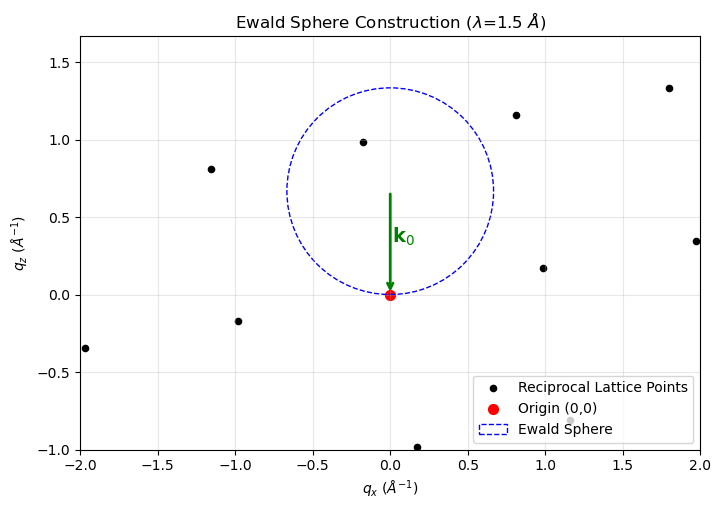

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ewald_sphere(wavelength_A, lattice_param_A, rotation_deg=0):
    k_radius = 1.0 / wavelength_A
    g_max = 2.0  # Max reciprocal lattice extent to plot
    
    # Reciprocal lattice points (Square lattice for simplicity)
    a_star = 1.0 / lattice_param_A
    gs = np.arange(-5, 6) * a_star
    gx, gy = np.meshgrid(gs, gs)
    
    # Rotate reciprocal lattice (simulating crystal tilt)
    theta = np.radians(rotation_deg)
    gx_rot = gx * np.cos(theta) - gy * np.sin(theta)
    gy_rot = gx * np.sin(theta) + gy * np.cos(theta)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot Reciprocal Lattice
    ax.scatter(gx_rot, gy_rot, c='black', s=20, label='Reciprocal Lattice Points')
    ax.scatter([0], [0], c='red', s=50, label='Origin (0,0)')
    
    # Plot Ewald Sphere (Circle in 2D)
    # Origin of sphere is at (0, k_radius) if incident beam is along -y (down)
    # Let's align incident k along negative Y in the plot, so k vector points to Origin.
    # Center of sphere is at (0, radius).
    
    sphere_center = (0, k_radius)
    circle = plt.Circle(sphere_center, k_radius, color='blue', fill=False, linestyle='--', label='Ewald Sphere')
    ax.add_patch(circle)
    
    # Plot Incident Vector k0
    ax.annotate("", xy=(0, 0), xytext=(0, k_radius), arrowprops=dict(arrowstyle="->", color='green', lw=2), label='k_0')
    ax.text(0.01, k_radius/2, r'$\mathbf{k}_0$', color='green', fontsize=14)
    
    # Limits
    ax.set_xlim(-g_max, g_max)
    ax.set_ylim(-0.5*g_max, 2.5*k_radius)
    ax.set_aspect('equal')
    ax.set_title(f'Ewald Sphere Construction ($\lambda$={wavelength_A} $\AA$)')
    ax.set_xlabel(r'$q_x$ ($\AA^{-1}$)')
    ax.set_ylabel(r'$q_z$ ($\AA^{-1}$)')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right')
    plt.show()

# Example: Low energy electrons (large lambda) for visualization
plot_ewald_sphere(wavelength_A=1.5, lattice_param_A=1.0, rotation_deg=10)

## 2. Bloch-Wave Concepts and Channeling

When an electron enters a crystal along a low-index zone axis, it feels the average potential of the atomic columns. The electron wavefunction can be expanded as a sum of **Bloch Waves**:

$$ \Psi(\mathbf{r}) = \sum_j C_j b_j(\mathbf{r}, \mathbf{k}) $$

where $b_j$ are the Bloch states. 

- **Type 1s**: Strongly bound to atomic columns (s-like symmetry), high density on nuclei.
- **Type 2p, ...**: Less bound.

This channeling effect explains why we see atomic columns in HAADF-STEM and HRTEM.

### Visualizing the Channeling Potential

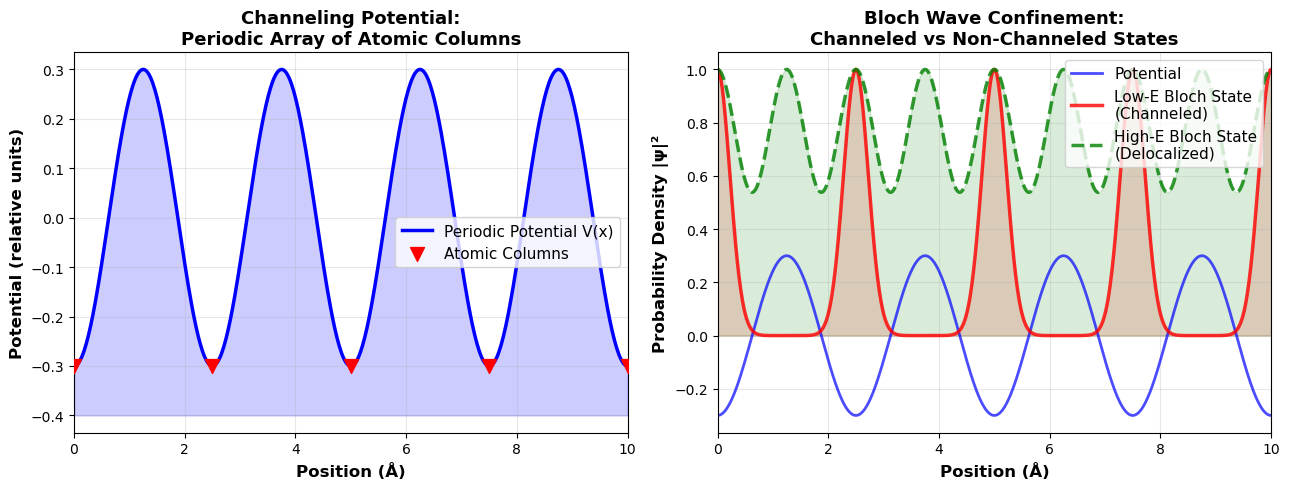

Channeling Effect Explanation:
• Low-energy Bloch states: Confined to atomic columns
  → High electron density on atoms → Strong scattering
  → Explains bright atomic columns in HAADF-STEM

• High-energy Bloch states: Extended throughout crystal
  → Weak localization → Weak scattering from individual atoms
  → Explains lower contrast at high energies

• Channeling is a quantum effect: electrons preferentially
  occupy energy bands with high density near atomic nuclei


In [5]:
# Visualize channeling potential (simplified 1D model)
# without requiring abtem (which has Python 3.10 compatibility issues)

def plot_channeling_potential():
    """
    Visualize 1D channeling potential and Bloch wavefunctions.
    This shows how electrons are confined to atomic columns.
    """
    # Create position array
    x = np.linspace(0, 10, 500)  # Distance in Angstroms
    
    # Create periodic potential (simulating atomic columns)
    V_channel = -0.3 * np.cos(2*np.pi * x / 2.5)  # Periodic wells
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    
    # Plot 1: Potential landscape
    ax1.plot(x, V_channel, 'b-', linewidth=2.5, label='Periodic Potential V(x)')
    ax1.fill_between(x, V_channel, -0.4, alpha=0.2, color='blue')
    
    # Mark atomic column positions
    atom_positions = np.arange(0, 11, 2.5)
    ax1.scatter(atom_positions, -0.3*np.ones_like(atom_positions), 
               c='red', s=100, marker='v', label='Atomic Columns', zorder=5)
    
    ax1.set_xlabel('Position (Å)', fontsize=12, weight='bold')
    ax1.set_ylabel('Potential (relative units)', fontsize=12, weight='bold')
    ax1.set_title('Channeling Potential:\nPeriodic Array of Atomic Columns', 
                 fontsize=13, weight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    ax1.set_xlim([0, 10])
    
    # Plot 2: Probability density of Bloch states
    # Low energy state (channeled - confined to columns)
    x_fine = np.linspace(0, 10, 1000)
    V_fine = -0.3 * np.cos(2*np.pi * x_fine / 2.5)
    
    # Low energy Bloch state: Gaussian wells at minima
    psi_low = np.zeros_like(x_fine)
    for x_0 in np.arange(0, 11, 2.5):
        psi_low += np.exp(-10*(x_fine - x_0)**2)
    psi_low = psi_low / np.max(psi_low)  # Normalize
    
    # High energy Bloch state: more delocalized
    psi_high = np.ones_like(x_fine) + 0.3*np.cos(4*np.pi*x_fine/2.5)
    psi_high = psi_high / np.max(psi_high)
    
    ax2.plot(x_fine, V_fine, 'b-', linewidth=2, label='Potential', alpha=0.7)
    ax2.plot(x_fine, psi_low, 'r-', linewidth=2.5, label='Low-E Bloch State\n(Channeled)', alpha=0.8)
    ax2.plot(x_fine, psi_high, 'g--', linewidth=2.5, label='High-E Bloch State\n(Delocalized)', alpha=0.8)
    
    ax2.fill_between(x_fine, psi_low, 0, alpha=0.15, color='red')
    ax2.fill_between(x_fine, psi_high, 0, alpha=0.15, color='green')
    
    ax2.set_xlabel('Position (Å)', fontsize=12, weight='bold')
    ax2.set_ylabel('Probability Density |ψ|²', fontsize=12, weight='bold')
    ax2.set_title('Bloch Wave Confinement:\nChanneled vs Non-Channeled States', 
                 fontsize=13, weight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11, loc='upper right')
    ax2.set_xlim([0, 10])
    
    plt.tight_layout()
    plt.show()
    
    print("Channeling Effect Explanation:")
    print("="*60)
    print("• Low-energy Bloch states: Confined to atomic columns")
    print("  → High electron density on atoms → Strong scattering")
    print("  → Explains bright atomic columns in HAADF-STEM")
    print()
    print("• High-energy Bloch states: Extended throughout crystal")
    print("  → Weak localization → Weak scattering from individual atoms")
    print("  → Explains lower contrast at high energies")
    print()
    print("• Channeling is a quantum effect: electrons preferentially")
    print("  occupy energy bands with high density near atomic nuclei")

# Run the visualization
plot_channeling_potential()

## 3. Diffraction Contrast Mechanisms

In conventional TEM (CTEM), image contrast often arises from dynamical diffraction effects.

### Two-Beam Condition
Often we tilt the crystal so that only one strong diffracted beam $\mathbf{g}$ is excited (plus the direct beam $\mathbf{0}$). The intensities oscillate with depth $t$:

$$ I_g(t) \propto \sin^2\left(\frac{\pi t}{\xi_{eff}}\right) $$

where $\xi_{eff} = \xi_g / \sqrt{1 + (s_g \xi_g)^2}$ is the effective extinction distance.

This leads to **Thickness Fringes**.

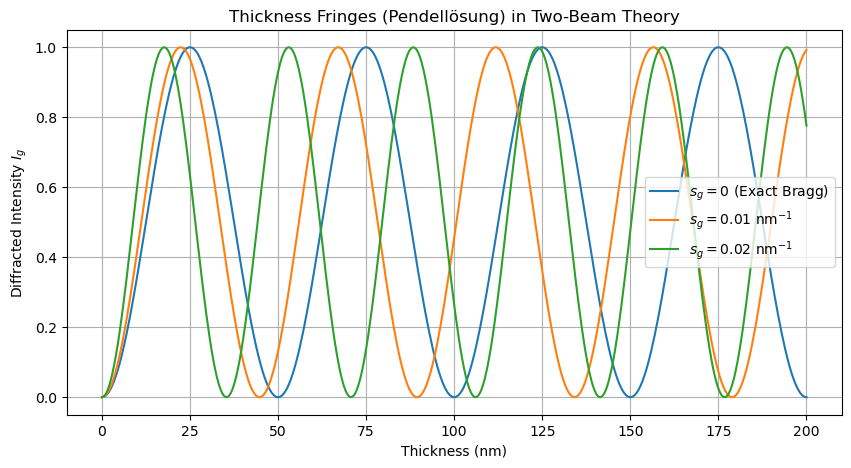

In [3]:
def two_beam_intensity(t, xi_g, s_g=0):
    """
    Calculate Diffracted Beam Intensity Ig(t)
    t: Thickness (nm)
    xi_g: Extinction distance (nm)
    s_g: Excitation error (nm^-1)
    """
    xi_eff = xi_g / np.sqrt(1 + (s_g * xi_g)**2)
    return np.sin(np.pi * t / xi_eff)**2

thickness = np.linspace(0, 200, 400) # 0 to 200 nm
xi_g = 50.0 # Example extinction distance

plt.figure(figsize=(10, 5))
plt.plot(thickness, two_beam_intensity(thickness, xi_g, s_g=0), label='$s_g=0$ (Exact Bragg)')
plt.plot(thickness, two_beam_intensity(thickness, xi_g, s_g=0.01), label='$s_g=0.01$ nm$^{-1}$')
plt.plot(thickness, two_beam_intensity(thickness, xi_g, s_g=0.02), label='$s_g=0.02$ nm$^{-1}$')
plt.title('Thickness Fringes (Pendellösung) in Two-Beam Theory')
plt.xlabel('Thickness (nm)')
plt.ylabel('Diffracted Intensity $I_g$')
plt.legend()
plt.grid(True)
plt.show()